In [2]:
!pip install polars

  Using cached polars-1.39.3-py3-none-any.whl.metadata (10 kB)
  Using cached polars_runtime_32-1.39.3-cp310-abi3-win_amd64.whl.metadata (1.5 kB)
Using cached polars-1.39.3-py3-none-any.whl (823 kB)
Using cached polars_runtime_32-1.39.3-cp310-abi3-win_amd64.whl (47.0 MB)

   ---------------------------------------- 0/2 [polars-runtime-32]
   ---------------------------------------- 0/2 [polars-runtime-32]
   ---------------------------------------- 0/2 [polars-runtime-32]
   -------------------- ------------------- 1/2 [polars]
   -------------------- ------------------- 1/2 [polars]
   -------------------- ------------------- 1/2 [polars]
   -------------------- ------------------- 1/2 [polars]
   -------------------- ------------------- 1/2 [polars]
   -------------------- ------------------- 1/2 [polars]
   -------------------- ------------------- 1/2 [polars]
   -------------------- ------------------- 1/2 [polars]
   -------------------- ------------------- 1/2 [polars]
   -------

📂 Loading data from c:\M5\data\processed\m5_improved.parquet...
🧠 Loading 9 LightGBM Quantile Models...
📊 Generating plot for FOODS_3_090_CA_3_evaluation...
['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'wday', 'month', 'sell_price', 'price_norm', 'roll_mean_7', 'roll_mean_28', 'snap_CA', 'snap_TX', 'snap_WI']


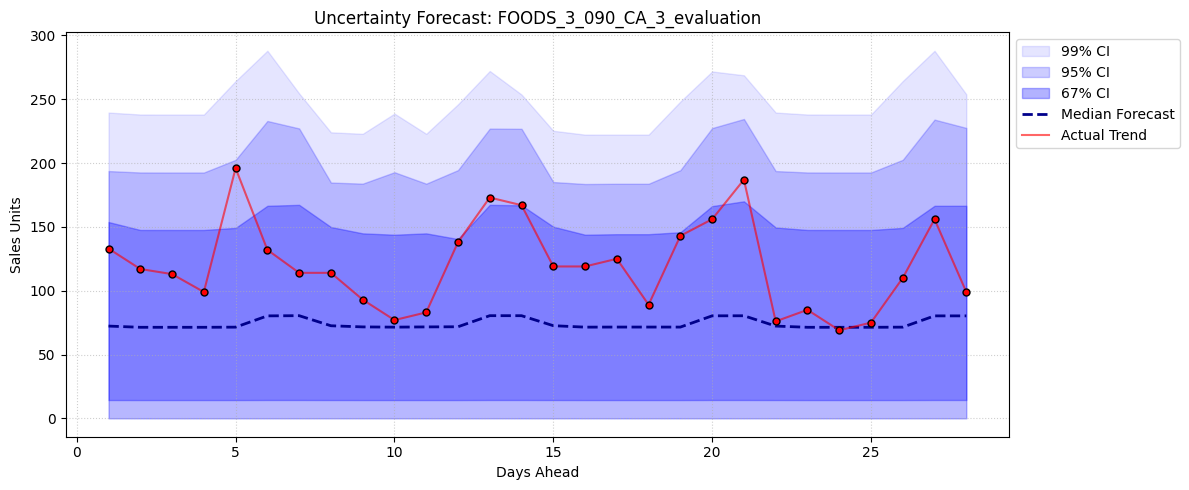

📊 Generating plot for HOBBIES_1_004_CA_1_evaluation...
['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'wday', 'month', 'sell_price', 'price_norm', 'roll_mean_7', 'roll_mean_28', 'snap_CA', 'snap_TX', 'snap_WI']


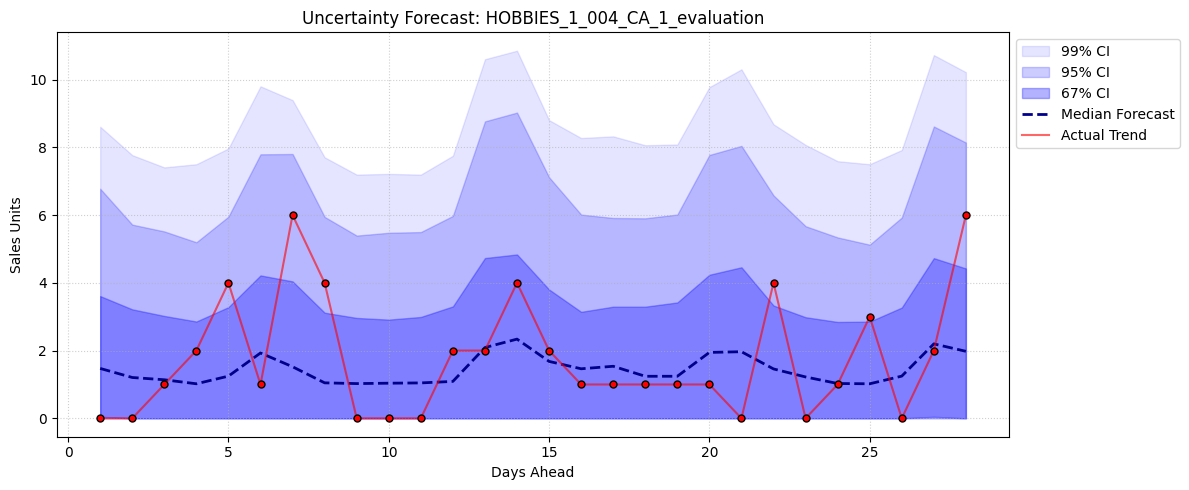

📊 Generating plot for HOUSEHOLD_1_001_TX_2_evaluation...
['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'wday', 'month', 'sell_price', 'price_norm', 'roll_mean_7', 'roll_mean_28', 'snap_CA', 'snap_TX', 'snap_WI']


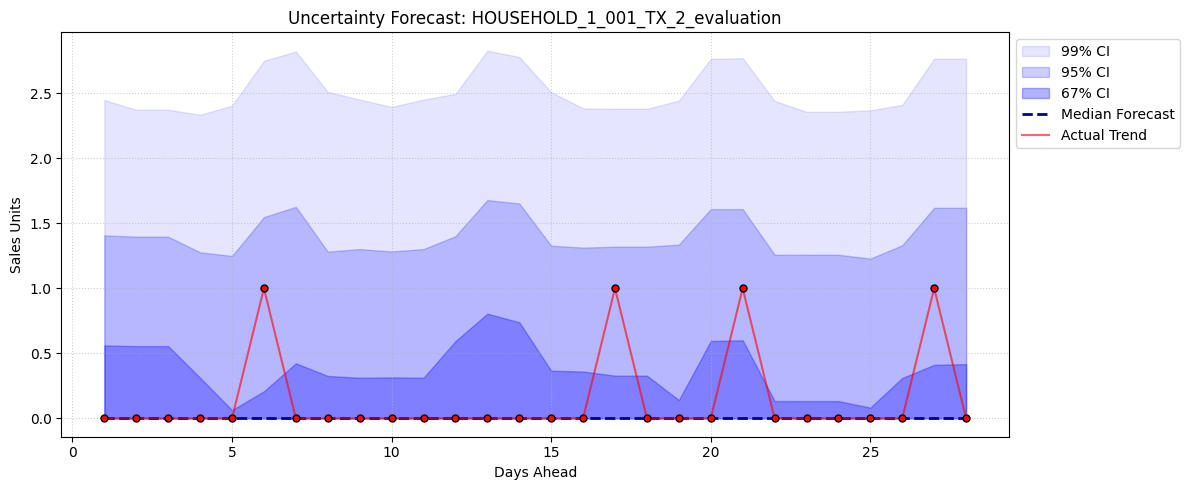

In [1]:
import polars as pl
import lightgbm as lgb
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
BASE_DIR = Path.cwd().parent
# Check if your folder is actually "models" or "models/model_alpha"
MODEL_DIR = BASE_DIR / "models" / "model_alpha"
DATA_PATH = BASE_DIR / "data" / "processed" / "m5_improved.parquet"
ALPHAS = [0.005, 0.025, 0.165, 0.25, 0.5, 0.75, 0.835, 0.975, 0.995]

def plot_multiple_items(item_list):
    # 1. Load Data Once
    print(f"📂 Loading data from {DATA_PATH}...")
    df = pl.read_parquet(DATA_PATH)
    
    features = [
        'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 
        'wday', 'month', 'sell_price', 'price_norm',
        'roll_mean_7', 'roll_mean_28',
        'snap_CA', 'snap_TX', 'snap_WI'
    ]
    
    # 2. Load Models Once into a dictionary
    print("🧠 Loading 9 LightGBM Quantile Models...")
    models = {}
    for alpha in ALPHAS:
        # Adjusted path to look directly in MODEL_DIR based on your train script
        model_path = MODEL_DIR / f"model_alpha_{alpha}.txt"
        models[alpha] = lgb.Booster(model_file=str(model_path))

    # 3. Loop through items and plot
    for item_id in item_list:
        print(f"📊 Generating plot for {item_id}...")
        
        # Filter for this specific item (last 28 days of data)
        test_df = df.filter((pl.col("id") == item_id) & (pl.col("d") > 1913)).head(28)
        
        if test_df.height == 0:
            print(f"⚠️ Warning: {item_id} not found or no data for evaluation period.")
            continue
            
        X_test = test_df.select(features).to_pandas()
        print(X_test.columns.tolist())
        actuals = test_df["sales"].to_numpy()
        days = range(1, len(actuals) + 1)
        
        # Run inference across all loaded models
        preds = {alpha: models[alpha].predict(X_test) for alpha in ALPHAS}

        # Create Plot
        plt.figure(figsize=(12, 5))
        
        # Uncertainty Ribbons
        plt.fill_between(days, preds[0.005], preds[0.995], color='blue', alpha=0.1, label='99% CI')
        plt.fill_between(days, preds[0.025], preds[0.975], color='blue', alpha=0.2, label='95% CI')
        plt.fill_between(days, preds[0.165], preds[0.835], color='blue', alpha=0.3, label='67% CI')

        # Forecast vs Actuals
        plt.plot(days, preds[0.5], color='darkblue', lw=2, ls='--', label='Median Forecast')
        plt.plot(days, actuals, color='red', lw=1.5, alpha=0.6, label='Actual Trend') 
        plt.scatter(days, actuals, color='red', s=25, edgecolors='black', zorder=5)

        plt.title(f"Uncertainty Forecast: {item_id}")
        plt.xlabel("Days Ahead")
        plt.ylabel("Sales Units")
        plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    # Add as many IDs as you want here!
    items_to_visualize = [
        "FOODS_3_090_CA_3_evaluation",
        "HOBBIES_1_004_CA_1_evaluation",
        "HOUSEHOLD_1_001_TX_2_evaluation"
    ]
    
    plot_multiple_items(items_to_visualize)
    